Data points: 10001
Time range:  0 – 100000 ps  (0.0 – 100.0 ns)

── Density Statistics ──
  Mean   : 1244.458 kg/m³
  Std    : 3.108 kg/m³
  Min    : 1232.568 kg/m³
  Max    : 1255.704 kg/m³
  Drift  : 9.257 kg/m³


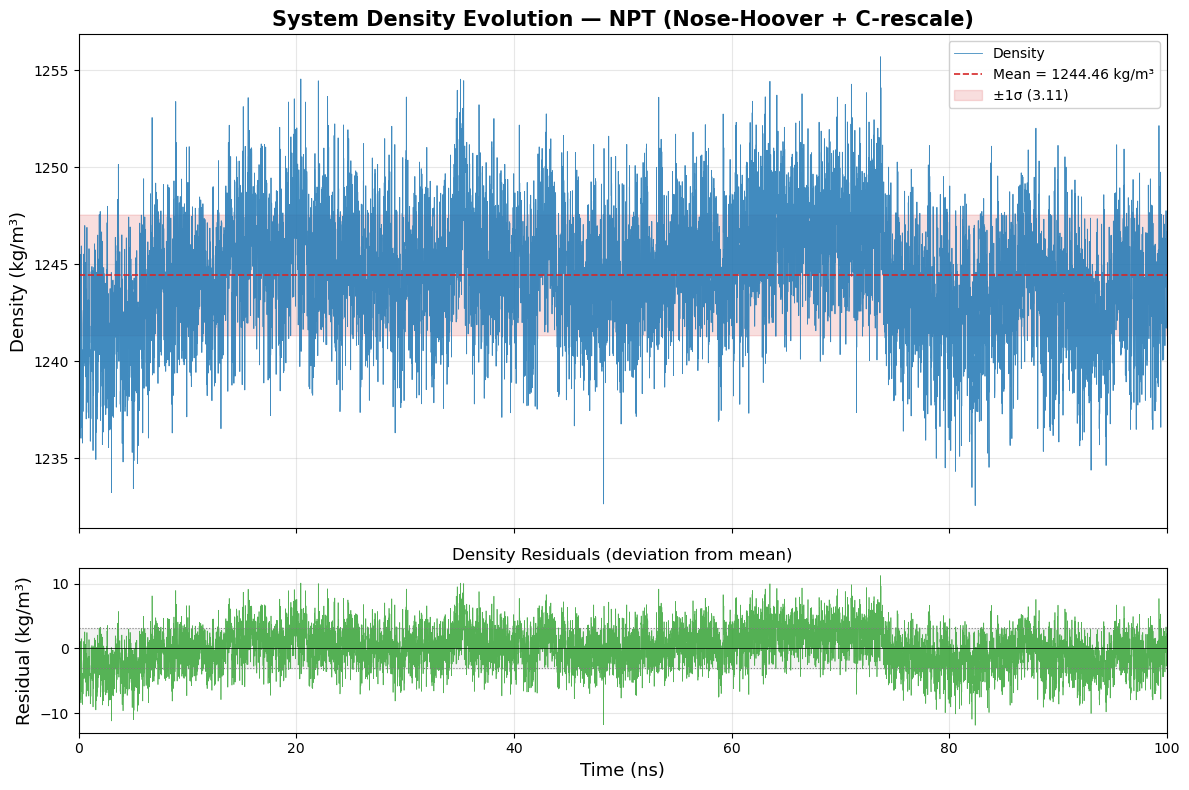


Plot saved to: system_density.png
Analysis complete.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Configuration ──────────────────────────────────────────────────
xvg_file = "density.xvg"
output_plot = "system_density.png"

# ── 1. Parse XVG file ──────────────────────────────────────────────
def parse_xvg(filepath):
    """Parse a GROMACS .xvg file, skipping comments and metadata."""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#') or line.startswith('@'):
                continue
            parts = line.split()
            if len(parts) >= 2:
                data.append([float(parts[0]), float(parts[1])])
    return np.array(data)

# Read data
data = parse_xvg(xvg_file)
time_ps = data[:, 0]          # Time in ps
time_ns = time_ps / 1000.0    # Convert to ns for nicer display
density = data[:, 1]          # Density in kg/m³

print(f"Data points: {len(data)}")
print(f"Time range:  {time_ps[0]:.0f} – {time_ps[-1]:.0f} ps  ({time_ns[0]:.1f} – {time_ns[-1]:.1f} ns)")

# ── 2. Compute statistics ──────────────────────────────────────────
mean_density   = np.mean(density)
std_density    = np.std(density)
min_density    = np.min(density)
max_density    = np.max(density)
drift          = density[-1] - density[0]

print(f"\n── Density Statistics ──")
print(f"  Mean   : {mean_density:.3f} kg/m³")
print(f"  Std    : {std_density:.3f} kg/m³")
print(f"  Min    : {min_density:.3f} kg/m³")
print(f"  Max    : {max_density:.3f} kg/m³")
print(f"  Drift  : {drift:.3f} kg/m³")

# ── 3. Plot ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), 
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

# ── Main density vs. time ──
ax1.plot(time_ns, density, linewidth=0.6, color='#1f77b4', alpha=0.85, label='Density')
ax1.axhline(y=mean_density, color='#d62728', linestyle='--', linewidth=1.2,
            label=f'Mean = {mean_density:.2f} kg/m³')
ax1.fill_between(time_ns, mean_density - std_density, mean_density + std_density,
                 alpha=0.15, color='#d62728', label=f'±1σ ({std_density:.2f})')

ax1.set_ylabel('Density (kg/m³)', fontsize=13)
ax1.set_title('System Density Evolution — NPT (Nose-Hoover + C-rescale)', fontsize=15, fontweight='bold')
ax1.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(time_ns[0], time_ns[-1])

# ── Residuals (deviation from mean) ──
residuals = density - mean_density
ax2.plot(time_ns, residuals, linewidth=0.5, color='#2ca02c', alpha=0.8)
ax2.fill_between(time_ns, -std_density, std_density, alpha=0.1, color='gray')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.axhline(y=std_density, color='gray', linestyle=':', linewidth=0.8)
ax2.axhline(y=-std_density, color='gray', linestyle=':', linewidth=0.8)

ax2.set_xlabel('Time (ns)', fontsize=13)
ax2.set_ylabel('Residual (kg/m³)', fontsize=13)
ax2.set_title('Density Residuals (deviation from mean)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_plot, dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot saved to: {output_plot}")
print("Analysis complete.")

